# Out of sample validation

A validation data set  $\mathcal{D}=\{ u^{(i)} \}_{i=1}^{N},$ will be provided to verify how well the optimized solutions are performing. Essentially, we are interested in evaluating their performace based on a few representative indicatos.

- ***THE PERFORMANCE FUNCTIONS*** defined by the 8 constraints as: $$g(a, u)= A_{in}a - b_{in}(u) \in \mathbb{R}^8$$
- ***THE WORST CASE PERFORMANCE SCORE***:  
  $$w (a^\star, \xi) = \min_{k\in{1,..,8}} g_k(a^\star, u) ~\forall~~ u\in \mathcal{D}.  $$
  The worst-case score tells us which one of the constriaint is closest to failure (lowest positive value) and the severity of failure (value for failing constraints). If $w<0$, at least one of rows of the system of linear inequalities is not sattisfied, i.e., $g_k \lt 0$.  
- ***FAILURE PROBABILITY*** Joint and individual requirements  
  $$P_{f,k}(a) = \mathbb{P}[ g_k(a, u)  < 0 ],k=1,...,8,$$
  $$P_{F}(a) = \mathbb{P}[ w (a, u)  < 0],$$
- ***RISK*** an indicator of the expected total load at risk during failure  
  $$Risk(a) = \mathbb{E}[u_{\text{total}} | w(a, u)<0],$$ where $$u_{\text{total}} = \sum_{i=1}^4 u_i$$ is the total demand at risk when the constraints are not sattisfied.

In [ ]:
# Imports
from sys import path
path.insert(0, '../src')

from scipy.optimize import linprog
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import pandas as pd
import numpy as np

from problem import c, u_nom, A_ineq, B, bounds, constraints_desc
from vis_utils import apply_plot_style, finalize_figure, setup_axes

from typing import Tuple, Dict, Any

apply_plot_style()

FIGS_PATH = Path("../assets/figs/output")
FIGS_PATH.mkdir(parents=True, exist_ok=True)

In [2]:
# load N validation samples
url_data_validation = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task4_validation.csv"

# Load the CSV into a numpy array
U_validation = pd.read_csv(url_data_validation).values

display(U_validation[:4]) # each row represent one load sample from the nodes

array([[22.87581693,  9.54413248, 28.75737631,  7.70178368],
       [21.18011024, 10.33357054, 25.54324909,  9.34753351],
       [27.89758103, 10.76856866, 27.42372243,  9.74349233],
       [21.34720374,  9.04970358, 26.21678702, 10.39955686]])

In [3]:
def solve_design_cases(cases: Dict[str, float], c: np.ndarray, A_ineq: np.ndarray, B: np.ndarray, u_nom: np.ndarray, bounds) -> Dict[str, Dict[str, Any]]:
    """Solve the LP for defined cases (epsilons).

    Parameters
    ----------
    cases : Dict[str, float]
        Mapping from case label to epsilon (e.g., {'Deterministic': 0.0}).
    c : np.ndarray
        Cost vector for the LP.
    A_ineq : np.ndarray
        Inequality constraint matrix A (8 x m).
    B : np.ndarray
        Demand-to-RHS mapping matrix (8 x 4).
    u_nom : np.ndarray
        Nominal demand vector (4,).
    bounds : sequence
        Variable bounds for the LP solver.

    Returns
    -------
    solutions : Dict[str, Dict[str, Any]]
        Dictionary keyed by case label containing 'eps', 'a', and 'cost'.
    """
    solutions: Dict[str, Dict[str, Any]] = {}

    for label, eps in cases.items():
        b_worst = B @ u_nom + eps * np.abs(B) @ u_nom
        result = linprog(c, A_ub=-A_ineq, b_ub=-b_worst, bounds=bounds, method='highs')

        if not result.success:
            raise RuntimeError(f"{label} optimization failed: {result.message}")

        solutions[label] = {
            'eps': eps,
            'a': result.x,
            'cost': result.fun,
        }

        print(f"{label}")
        print(f"  x* = {result.x[:3].round(2)},  y* = {result.x[3:].round(2)},  cost = {result.fun:.2f}\n")

    return solutions

cases = {
    "Deterministic": 0.00,
    "Robust (eps=10%)": 0.10,
    "Robust (eps=20%)": 0.20,
    "Robust (eps=30%)": 0.30,
}

solutions = solve_design_cases(cases, c, A_ineq, B, u_nom, bounds)

Deterministic
  x* = [10. 47. 10.],  y* = [-0. 22.  0.],  cost = 319.00

Robust (eps=10%)
  x* = [10.  53.7 10. ],  y* = [ 1.  31.2  1. ],  cost = 385.90

Robust (eps=20%)
  x* = [10.  60.4 10. ],  y* = [ 2.  40.4  2. ],  cost = 452.80

Robust (eps=30%)
  x* = [10.  67.1 10. ],  y* = [ 3.  49.6  3. ],  cost = 519.70



We select uncertainty (eps) of 20% in order to balance cost and robustness

In [4]:
eps = 20 # [%]
det_design = solutions["Deterministic"]['a']
robust_design = solutions[f"Robust (eps={eps}%)"]['a']

## Task 4.1 - Visualize the empirical PDF and CDF of the indicators

By using $\mathcal{D}$. Compare $a^\star_{det}$ and $a^\star_{unc}$. Visualize the probability density functions (PDFs) and cumulative distribution functions (CDFs) of the worst-case violation score $w$ together with the violation scores $g_k$ on the individual capcity requirements (code and text cells).

In [5]:
def evaluate_design(a: np.ndarray, A_ineq: np.ndarray, B: np.ndarray, U: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Evaluate a design on validation samples.

    Parameters
    ----------
    a : np.ndarray
        Design vector [x*, y*].
    A_ineq : np.ndarray
        Constraint matrix.
    B : np.ndarray
        Mapping matrix from demands to RHS.
    U : np.ndarray
        Validation samples with shape (N_samples, 4).

    Returns
    -------
    g : np.ndarray
        Performance function values with shape (N_samples, 8).
    w : np.ndarray
        Worst-case violation with shape (N_samples,).
    """

    # U shape: (N_samples, 4)
    # B shape: (8, 4)
    # b_vals should be (N_samples, 8)
    b_vals = U @ B.T  # (N, 4) @ (4, 8) -> (N, 8)

    # Compute g(a, u) = A_in @ a - b
    # A_ineq @ a gives a (8,) array
    # We need to broadcast: (1, 8) - (N_samples, 8) -> (N_samples, 8)
    g =  (A_ineq @ a).reshape(1, -1) - b_vals

    # Worst-case performance: w = min_k g_k for each sample
    w = np.min(g, axis=1)
    return g, w

# Evaluate both designs on validation data
g_det, w_det = evaluate_design(det_design, A_ineq, B, U_validation)
g_robust, w_robust = evaluate_design(robust_design, A_ineq, B, U_validation)

Worst-case performance summary:

Deterministic Design:
  Mean w(a,u): -2.71
  Std w(a,u): 1.87
  Min w(a,u): -16.05
  Max w(a,u): -0.04
  P[w(a,u) < 0]: 1.0000

Robust Design (eps=20%):
  Mean w(a,u): 0.83
  Std w(a,u): 0.64
  Min w(a,u): -3.39
  Max w(a,u): 1.99
  P[w(a,u) < 0]: 0.1007


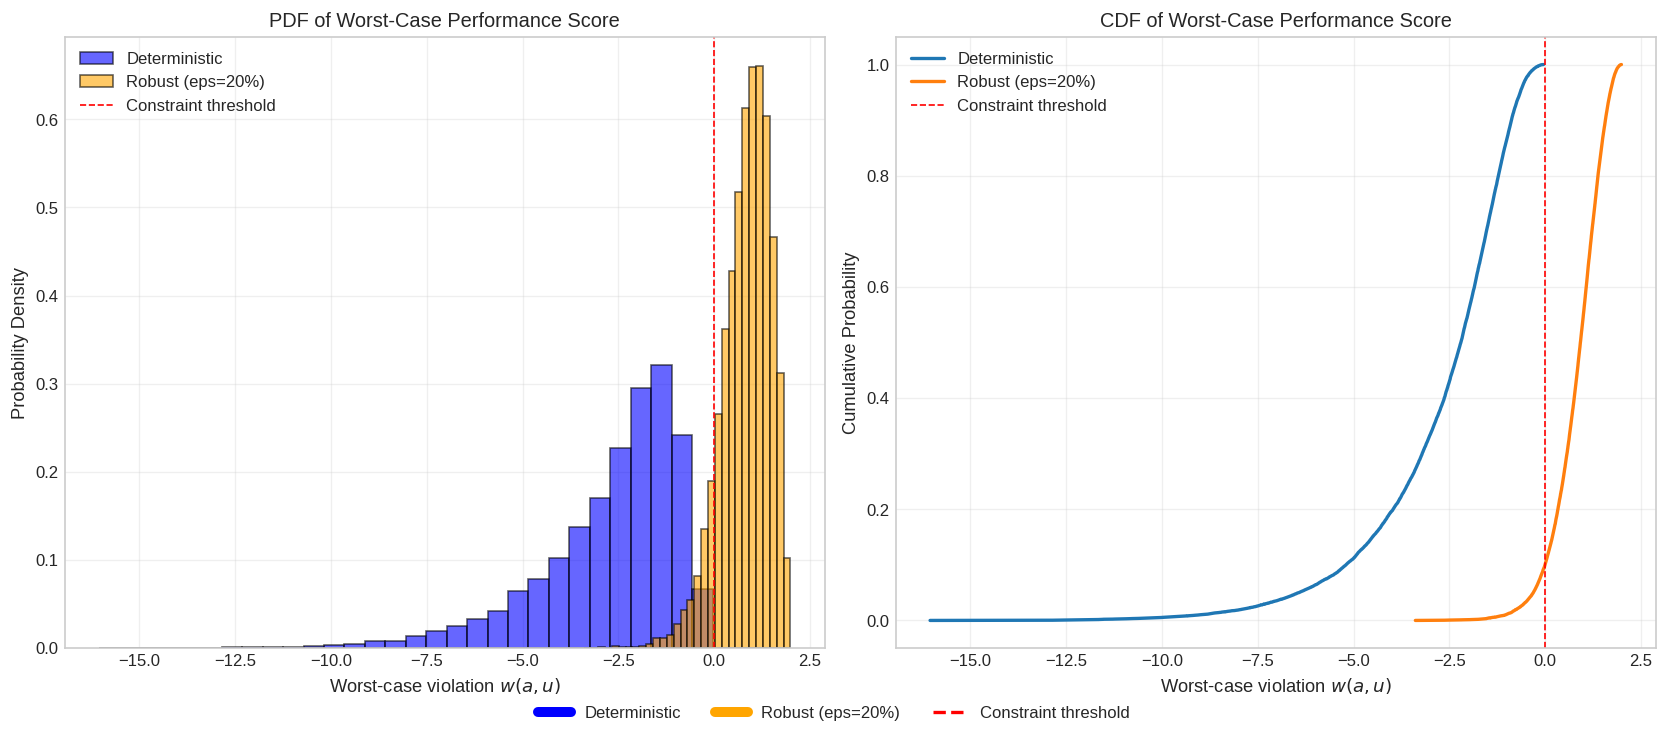

In [6]:
# Summary statistics
print("Worst-case performance summary:")
print(f"\nDeterministic Design:")
print(f"  Mean w(a,u): {np.mean(w_det):.2f}")
print(f"  Std w(a,u): {np.std(w_det):.2f}")
print(f"  Min w(a,u): {np.min(w_det):.2f}")
print(f"  Max w(a,u): {np.max(w_det):.2f}")
print(f"  P[w(a,u) < 0]: {np.sum(w_det < 0) / len(w_det):.4f}")

print(f"\nRobust Design (eps={eps}%):")
print(f"  Mean w(a,u): {np.mean(w_robust):.2f}")
print(f"  Std w(a,u): {np.std(w_robust):.2f}")
print(f"  Min w(a,u): {np.min(w_robust):.2f}")
print(f"  Max w(a,u): {np.max(w_robust):.2f}")
print(f"  P[w(a,u) < 0]: {np.sum(w_robust < 0) / len(w_robust):.4f}")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Histogram and PDF of worst-case performance
ax = axes[0]
ax.hist(w_det, bins=30, density=True, alpha=0.6, label='Deterministic', color='blue', edgecolor='black')
ax.hist(w_robust, bins=30, density=True, alpha=0.6, label=f'Robust (eps={eps}%)', color='orange', edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='Constraint threshold')
setup_axes(ax, xlabel='Worst-case violation $w(a, u)$', ylabel='Probability Density', title='PDF of Worst-Case Performance Score', legend=True)

# 2. CDF of worst-case performance
ax = axes[1]
w_det_sorted = np.sort(w_det)
w_robust_sorted = np.sort(w_robust)
ax.plot(w_det_sorted, np.arange(1, len(w_det_sorted)+1)/len(w_det_sorted), label='Deterministic', linewidth=2)
ax.plot(w_robust_sorted, np.arange(1, len(w_robust_sorted)+1)/len(w_robust_sorted), label=f'Robust (eps={eps}%)', linewidth=2)
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='Constraint threshold')
setup_axes(ax, xlabel='Worst-case violation $w(a, u)$', ylabel='Cumulative Probability', title='CDF of Worst-Case Performance Score', legend=True)

# Single legend for the figure
handles = [Line2D([0], [0], color='blue', lw=6), Line2D([0], [0], color='orange', lw=6), Line2D([0], [0], color='red', lw=2, linestyle='--')]
labels = ['Deterministic', f'Robust (eps={eps}%)', 'Constraint threshold']
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.03), frameon=False, fontsize=10)

finalize_figure(fig, FIGS_PATH / 'task41_performance_analysis.png', show=True)


### Findings

Validation samples separate the two designs cleanly. The deterministic design has a negative worst-case score on every sample, so it fails at least one constraint with probability 1.0. The robust design shifts the distribution to the right and reduces its deviation leaving only a small left tail. In practice, the extra capacity purchased under uncertainty provides better feasibility on unseen demand, even if it does not eliminate risk entirely.

## Task 4.2 - Estimate these probabilities and discuss the results

Etimate $P_{f,k}(a),k=1,...,8,$ and $P_{F}(a)$ for the deterministic design, from task 1, and the design under uncertainty, from task 3. Discuss your findings and present a convergence plot to check for stability of the estimator. What is the most critical part of the network? Which constraints are most likely to fail?  How often does each design (deterministic and uncertain) violate constraints? (code and text cells).

In [7]:
def compute_failure_probabilities(g: np.ndarray, w: np.ndarray) -> Tuple[np.ndarray, float]:
    """Compute failure probabilities for individual constraints and overall.

    Parameters
    ----------
    g : np.ndarray
        Performance values with shape (N_samples, 8).
    w : np.ndarray
        Worst-case violation values with shape (N_samples,).

    Returns
    -------
    pf_k : np.ndarray
        Individual failure probabilities for each constraint (shape (8,)).
    pf_total : float
        Overall failure probability P[w < 0].
    """
    pf_k = np.sum(g < 0, axis=0) / len(g)
    pf_total = float(np.sum(w < 0) / len(w))
    return pf_k, pf_total

# Estimate probabilities for both designs
pf_det_k, pf_det_total = compute_failure_probabilities(g_det, w_det)
pf_robust_k, pf_robust_total = compute_failure_probabilities(g_robust, w_robust)

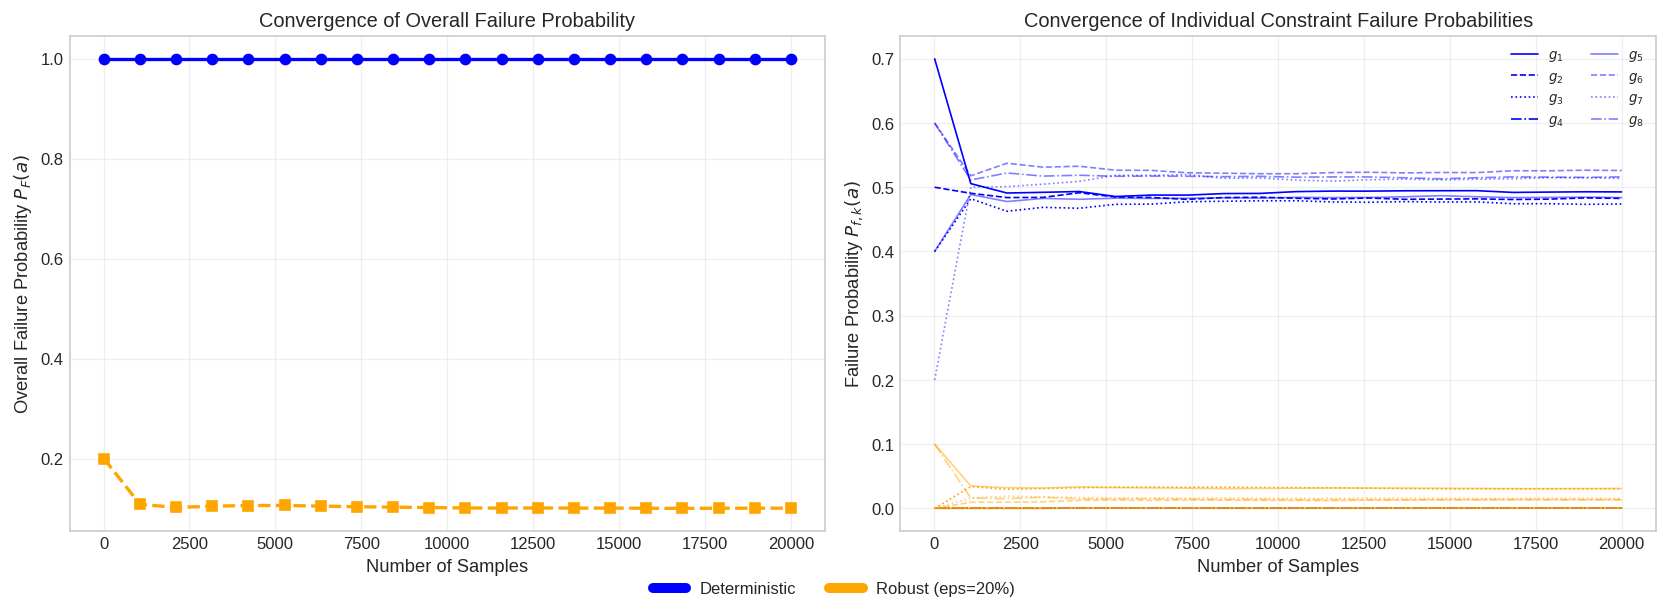

In [8]:
# Compute convergence estimates with increasing sample sizes
sample_sizes = np.linspace(10, len(g_det), 20, dtype=int)
pf_det_k_conv = []
pf_robust_k_conv = []
pf_det_total_conv = []
pf_robust_total_conv = []

for n in sample_sizes:
    pf_k_tmp, pf_total_tmp = compute_failure_probabilities(g_det[:n], w_det[:n])
    pf_det_k_conv.append(pf_k_tmp)
    pf_det_total_conv.append(pf_total_tmp)
    pf_k_tmp, pf_total_tmp = compute_failure_probabilities(g_robust[:n], w_robust[:n])
    pf_robust_k_conv.append(pf_k_tmp)
    pf_robust_total_conv.append(pf_total_tmp)

pf_det_k_conv = np.array(pf_det_k_conv)
pf_robust_k_conv = np.array(pf_robust_k_conv)

# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall failure probability convergence
ax = axes[0]
ax.plot(sample_sizes, pf_det_total_conv, 'o-', label='Deterministic', color='blue')
ax.plot(sample_sizes, pf_robust_total_conv, 's--', label=f'Robust (eps={eps}%)', color='orange')
setup_axes(ax, xlabel='Number of Samples', ylabel='Overall Failure Probability $P_F(a)$', title='Convergence of Overall Failure Probability')

# Individual constraint probabilities convergence
ax = axes[1]
linestyles = ['-', '--', ':', '-.']
opacities = [1, 0.5]

for k in range(8):
    ax.plot(sample_sizes, pf_det_k_conv[:, k], linestyle=linestyles[k % 4], color="blue", alpha=opacities[k // 4], linewidth=1, label=f'$g_{k+1}$')
    ax.plot(sample_sizes, pf_robust_k_conv[:, k], linestyle=linestyles[k % 4], color="orange", alpha=opacities[k // 4], linewidth=1)

setup_axes(ax, xlabel='Number of Samples', ylabel='Failure Probability $P_{f,k}(a)$', title='Convergence of Individual Constraint Failure Probabilities', legend=True, legend_kwargs={'ncol': 2, 'fontsize': 8})

# Single legend for the figure
handles = [Line2D([0], [0], color='blue', lw=6), Line2D([0], [0], color='orange', lw=6)]
labels = ['Deterministic', f'Robust (eps={eps}%)']
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.03), frameon=False, fontsize=10)


finalize_figure(fig, FIGS_PATH / 'task42_failure_probabilities.png')

Individual Constraint Failure Probabilities P_{f,k}(a):
Constraint                              	       Deterministic     Robust (eps=20%)
----------------------------------------------------------------------------------------------------
g_1: Total generation >= total demand        	            0.492750             0.000400
g_2: Inflow at node 1 >= demand at node 1    	            0.482650             0.000000
g_3: Node 2: x2 + y1 >= u2                   	            0.473900             0.030700
g_4: Node 3: x3 + y2 >= u3                   	            0.000000             0.000000
g_5: Node 4: x4 + y3 >= u4                   	            0.483900             0.030850
g_6: Line 1 excess capacity                  	            0.526100             0.013750
g_7: Line 2 excess capacity                  	            0.513750             0.015500
g_8: Line 3 excess capacity                  	            0.516100             0.013250

-------------------------------------------------------

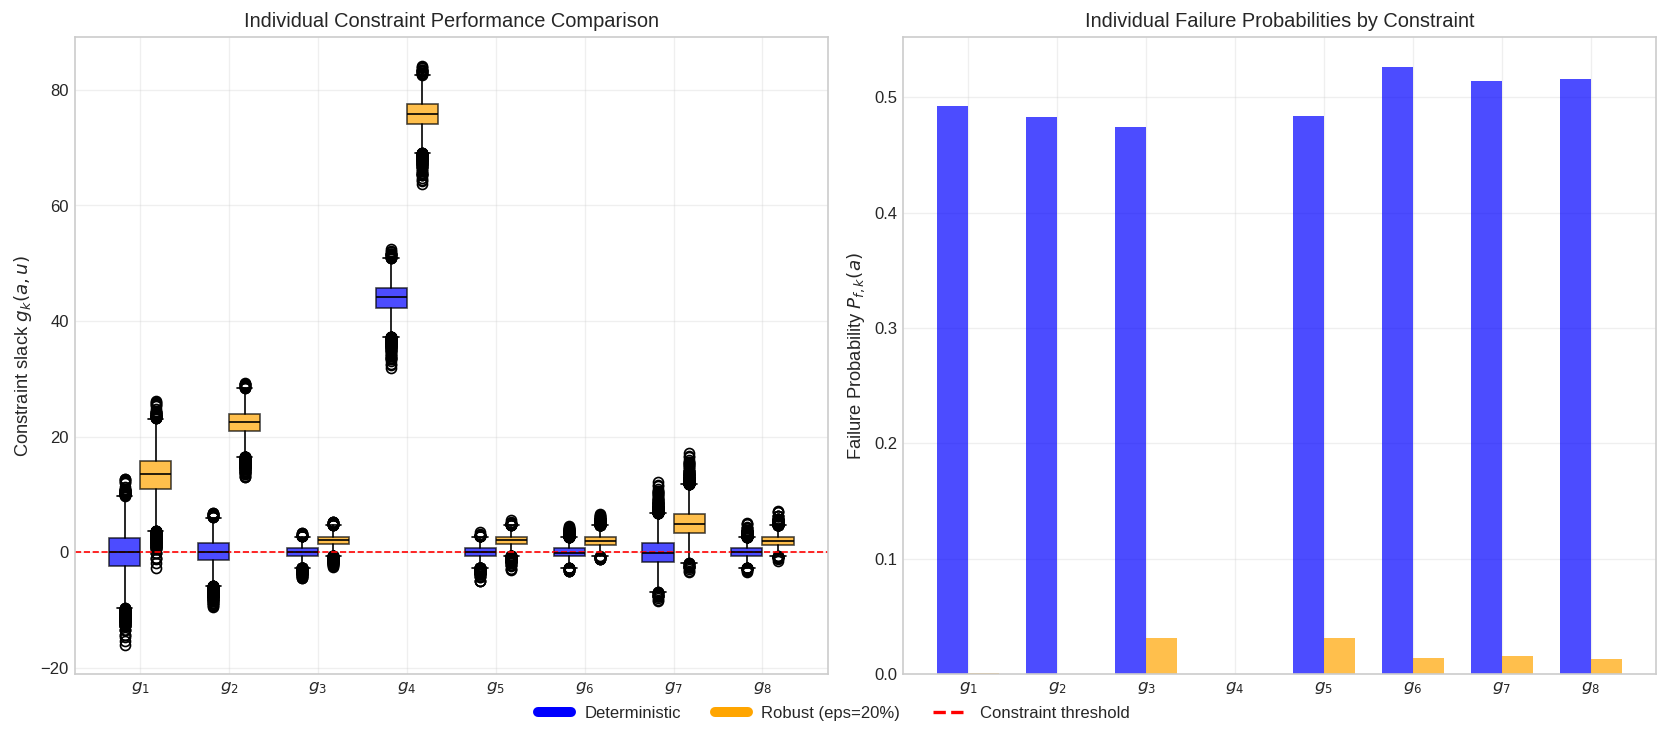

In [9]:
# Print Summary
print("Individual Constraint Failure Probabilities P_{f,k}(a):")
print(f"{'Constraint':<40}\t{'Deterministic':>20} {f'Robust (eps={eps}%)':>20}")
print("-" * 100)

for i, desc in enumerate(constraints_desc):
    print(f"g_{i+1}: {desc:<40}\t{pf_det_k[i]:>20f} {pf_robust_k[i]:>20f}")

print("\n" + "-" * 100)
print(f"{'Overall P_F(a)':<40}\t{pf_det_total:>20f} {pf_robust_total:>20f}")

# Max/Min failure probabilities
det_max_idx = int(np.argmax(pf_det_k))
det_min_idx = int(np.argmin(pf_det_k))
rob_max_idx = int(np.argmax(pf_robust_k))
rob_min_idx = int(np.argmin(pf_robust_k))
print("\nMax/Min failure probabilities (per design):")
print(f"Deterministic : {pf_det_k[det_min_idx]:.4f} (g_{det_min_idx+1}) - {pf_det_k[det_max_idx]:.4f} (g_{det_max_idx+1})")
print(f"Robust        : {pf_robust_k[rob_min_idx]:.4f} (g_{rob_min_idx+1}) - {pf_robust_k[rob_max_idx]:.4f} (g_{rob_max_idx+1})")

# Create boxplot (individual constraints) + failure probability by constraint
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot comparison of individual constraints (paired per constraint)
ax = axes[0]
constraint_labels = [f'$g_{i+1}$' for i in range(8)]
positions = np.arange(8)
width = 0.35
bp_det = ax.boxplot([g_det[:, i] for i in range(8)], positions=positions - width/2, widths=width, patch_artist=True, manage_ticks=False)
bp_rob = ax.boxplot([g_robust[:, i] for i in range(8)], positions=positions + width/2, widths=width, patch_artist=True, manage_ticks=False)
for patch in bp_det['boxes']:
    patch.set_facecolor('blue')
    patch.set_alpha(0.7)
for patch in bp_rob['boxes']:
    patch.set_facecolor('orange')
    patch.set_alpha(0.7)
for median in bp_det['medians'] + bp_rob['medians']:
    median.set_color('black')
ax.set_xticks(positions)
ax.set_xticklabels(constraint_labels)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Constraint threshold')
setup_axes(ax, ylabel='Constraint slack $g_k(a, u)$', title='Individual Constraint Performance Comparison', legend=False)

# Failure probability by constraint
ax = axes[1]
pf_det = np.sum(g_det < 0, axis=0) / len(g_det)
pf_robust = np.sum(g_robust < 0, axis=0) / len(g_robust)

x_pos = np.arange(8)
width = 0.35
ax.bar(x_pos - width/2, pf_det, width, label='Deterministic', color='blue', alpha=0.7)
ax.bar(x_pos + width/2, pf_robust, width, label=f'Robust (eps={eps}%)', color='orange', alpha=0.7)
setup_axes(ax, ylabel='Failure Probability $P_{f,k}(a)$', title='Individual Failure Probabilities by Constraint')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'$g_{i+1}$' for i in range(8)])

# Single legend for the figure
handles = [Line2D([0], [0], color='blue', lw=6), Line2D([0], [0], color='orange', lw=6), Line2D([0], [0], color='red', lw=2, linestyle='--')]
labels = ['Deterministic', f'Robust (eps={eps}%)', 'Constraint threshold']
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.03), frameon=False, fontsize=10)

finalize_figure(fig, FIGS_PATH / 'task42_individual_constraints.png', show=True)

### Findings

**Convergence:**

The convergence curves flatten very quickly after a few thousand samples both for overall and individual constraint failure probabilities, so the Monte Carlo estimates are stable and the ranking of the critical constraints is consistent.

**Constraint Failure Probabilities:**

From indivdual constraint failure analysis we can see that both deterministic and robust designs successfully satisfy node 3 constraint all the time. This is expected since node 3 is the one to be main provider for the consumer node 1. 

For the rest of constraints the deterministic design sits around 50% violation rate, while robust design reduces every constraint 10x with the highest probability of failing at least one constraint being 10.0% (compared to deterministic 100%). 

Robust design successfully satisfies constraints on total generating and inflow at the node 1 to beenough to satisfy respective demand. It is expected since node 1 serves as a transition hub for nodes 2 and 4 which always provides it with enough electricity.

For both designs constraints related to the nodes 2 and 4 and their connections (g3, g5, g6, g8) are the main problem - they are expected to provide energy for themselves, but unable to do so for cases where their demand exceeds generation and connection capacity. Also, connection between nodes 1 and 3 fails to satisfy capacity on approximately the same level as other connections.


## Task 4.3 - Estimate the demand at risk when we fail
Estimate the risk $Risk(a)$ for both designs.  Present a convergence plot to check if the estimator is stable.  (code and text cells)

In [10]:
def compute_risk(w: np.ndarray, U: np.ndarray, threshold: float = 0.0) -> Tuple[float, float, float]:
    """Compute expected demand at risk for failure scenarios.

    Parameters
    ----------
    w : np.ndarray
        Worst-case violation scores (N_samples,).
    U : np.ndarray
        Demand data with shape (N_samples, 4).
    threshold : float, optional
        Failure threshold (default 0.0).

    Returns
    -------
    risk : float
        Expected total demand at risk (E[u_total | failure]).
    risk_std : float
        Standard deviation of demand at risk.
    prob_failure : float
        Probability of failure (fraction of samples where w < threshold).
    """
    # Identify failure scenarios
    failure_mask = w < threshold
    
    if np.sum(failure_mask) == 0:
        return 0.0, 0.0, 0.0

    # Total demand for each sample
    u_total = np.sum(U, axis=1)
    
    # Demand at risk during failures
    u_at_risk = u_total[failure_mask]

    risk = float(np.mean(u_at_risk))
    risk_std = float(np.std(u_at_risk))
    prob_failure = float(np.mean(failure_mask))

    return risk, risk_std, prob_failure

risk_det, risk_det_std, pf_det_risk = compute_risk(w_det, U_validation)
risk_robust, risk_robust_std, pf_robust_risk = compute_risk(w_robust, U_validation)

Deterministic Design:
  Probability of failure: 1.0000
  Expected demand at risk: 67.05 pu
  Std dev of demand at risk: 3.65 pu

Robust Design (eps=20%):
  Probability of failure: 0.1007
  Expected demand at risk: 67.14 pu
  Std dev of demand at risk: 4.70 pu


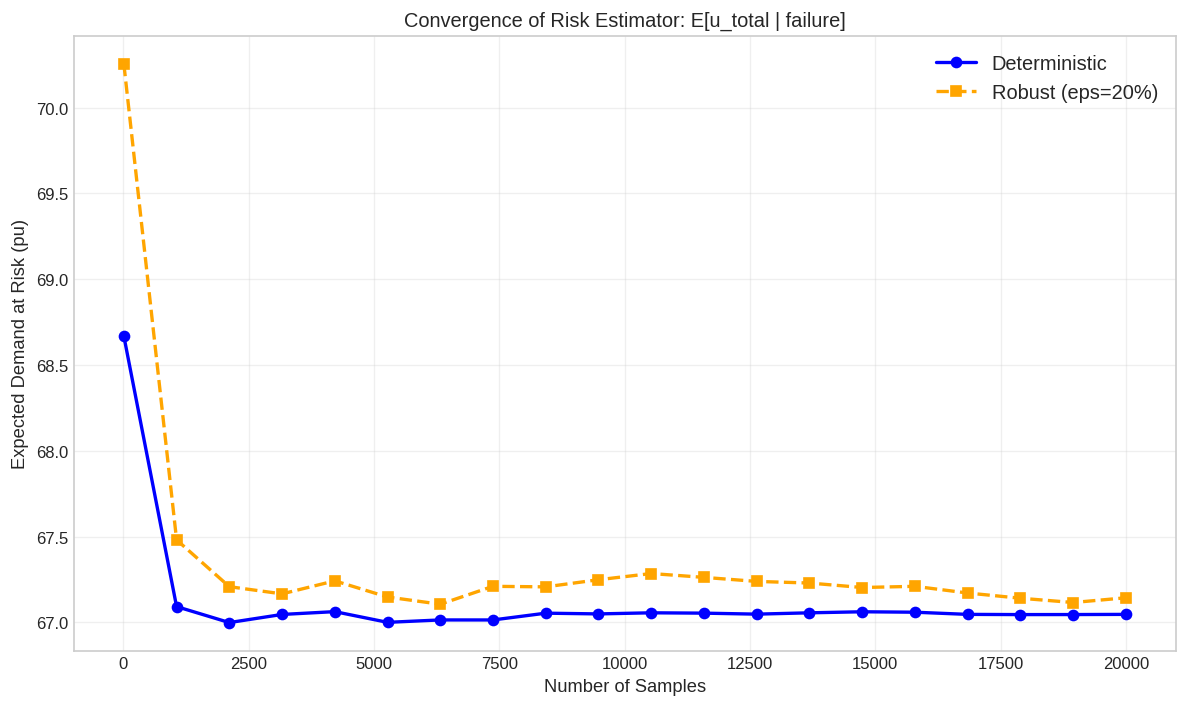

In [11]:
print(f"Deterministic Design:")
print(f"  Probability of failure: {pf_det_risk:.4f}")
print(f"  Expected demand at risk: {risk_det:.2f} pu")
print(f"  Std dev of demand at risk: {risk_det_std:.2f} pu")

print(f"\nRobust Design (eps={eps}%):")
print(f"  Probability of failure: {pf_robust_risk:.4f}")
print(f"  Expected demand at risk: {risk_robust:.2f} pu")
print(f"  Std dev of demand at risk: {risk_robust_std:.2f} pu")

# Compute convergence with increasing sample size
risk_det_conv = []
risk_robust_conv = []

for n in sample_sizes:
    risk_tmp, _, _ = compute_risk(w_det[:n], U_validation[:n])
    risk_det_conv.append(risk_tmp)

    risk_tmp, _, _ = compute_risk(w_robust[:n], U_validation[:n])
    risk_robust_conv.append(risk_tmp)

# Plot convergence
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sample_sizes, risk_det_conv, 'o-', linewidth=2, markersize=6, label='Deterministic', color='blue')
ax.plot(sample_sizes, risk_robust_conv, 's--', linewidth=2, markersize=6, label=f'Robust (eps={eps}%)', color='orange')

setup_axes(ax, xlabel='Number of Samples', ylabel='Expected Demand at Risk (pu)', title='Convergence of Risk Estimator: E[u_total | failure]', legend=True, legend_kwargs={'fontsize': 12})

finalize_figure(fig, FIGS_PATH / 'task43_demand_at_risk.png')


### Findings

The risk metric provides the total demand seen when the network is already failing. Since the deterministic design fails almost everywhere, its conditional risk is expected to be close to the average validation demand. The robust design fails much less often, but when it does fail the associated demand level can still be comparable, so the main benefit is reducing how often the system enters failure rather than dramatically changing the severity of failing scenarios.

The risk estimator converges rapidly for both designs. The deterministic plan has failure probability 1.0 and a conditional demand at risk of about 67.05 pu, while the 20% robust design lowers the failure probability to about 10.07% with a very similar conditional demand at risk of about 67.14 pu. This confirms that robustness mainly reduces the frequency of failure, not the demand magnitude observed once failure occurs.